# Импорты

In [ ]:
!git clone https://github.com/evagogua/denoiseML

Cloning into 'denoiseML'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 104 (delta 30), reused 45 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 6.01 MiB | 4.22 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
!pip install -r "/content/denoiseML/requirements.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely n

In [ ]:
import sys
import os

repo_name = "denoiseML"
os.chdir(f'/content/{repo_name}')

from src.models.denoise_model import (
    DenoiseDataset,
    make_last_subtoken_mask,
    prepare_denoise_dataset_from_json
)
from src.inference.denoiser import (
    denoising,
    predict_with_trainer,
    evaluate_on_test_set,
    test
)
from src.models.trainer import (
    plot_training_curves,
    compute_metrics,
    final_report
)

# Обучение

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")
model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### banking+credit_cards

In [ ]:
train_banking_credit_noise_dataset, test_banking_credit_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_banking_credit.json', tokenizer, test_size=0.2, seed=42, verbose=True)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['на', 'что', 'татумастер', 'годятся', 'мя', 'мои', 'несчаст', 'шедевры', 'понятно'], 'denoise_labels': ['0', '0', 'N', '0', 'N', '0', 'N', '0', 'N'], 'classification_labels': 'redeem_rewards'}

Пример из train (после токенизации):
{'input_ids': [0, 29, 414, 145075, 723, 12544, 5532, 32369, 36110, 64816, 19671, 28312, 65110, 1125, 12957, 227, 93870, 2], 'mask': [False, True, True, False, False, True, False, True, True, True, False, True, False, False, False, True, True, False], 'labels': array([-100,    0,    0, -100, -100,    1, -100,    0,    1,    0, -100,
          1, -100, -100, -100,    0,    1, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

banking_credit_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=2)
optimizer = AdamW(banking_credit_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=100, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
banking_credit_denoise_trainer = Trainer(
    model=banking_credit_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_banking_credit_noise_dataset,
    eval_dataset=test_banking_credit_noise_dataset,
    compute_metrics=compute_metrics)
banking_credit_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
final_report(banking_credit_denoise_trainer, test_banking_credit_noise_dataset)

Step,Training Loss,Validation Loss


KeyboardInterrupt: 

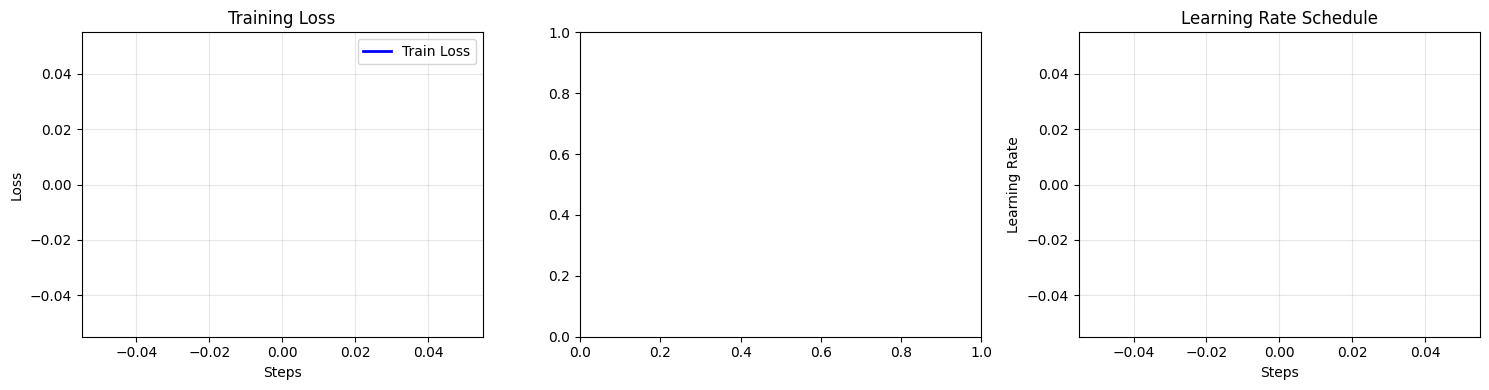

In [ ]:
plot_training_curves(banking_credit_denoise_trainer)

In [ ]:
evaluate_on_test_set(
    trainer=banking_credit_denoise_trainer,
    tokenizer=tokenizer,
    test_samples=test
)

Step,Training Loss,Validation Loss


переведите деньги на мой счет
N N N N N
0 0 0 0 0
0/5
алиса какой канал переведите сто долларов на сберкнижку
N N N N N N N N
N N N 0 0 0 0 0
3/8
выключи телевизор заблокируй карту срочно пожалуйста
N N N N N N
N N 0 0 0 0
2/6
привет как дела что делаешь переведи пять тысяч на вклад
N N N N N N N N N N
N N N N N 0 0 0 0 0
5/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
N N N N N N N N N N N
N N N N N N N N 0 0 0
8/11
какой баланс моей карты
N N N N
0 0 0 0
0/4
погода сегодня алиса какой баланс на карте
N N N N N N N
N N N 0 0 0 0
3/7
переведи деньги срочно сделай тише я сказал
N N N N N N N
0 0 0 N N N N
4/7
перевод средств на карту сбербанка
N N N N N
0 0 0 0 0
0/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
N N N N N N N N N N
N N N N N N N 0 0 0
7/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    43.84%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 0.00%
  Recall:    0.00%
  F1:        0.00%

КЛАСС N (ШУМ):
  Precision: 43.84%
  Recall:    100.00%
  F1:        60.9

In [ ]:
model_save_path = "banking_credit_denoise_model"
banking_credit_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### all_labels

In [ ]:
train_full_noise_dataset, test_full_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_all.json', tokenizer, test_size=0.2, seed=42, verbose=True)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['мне', 'нужна', 'сигнализация', 'чтобы', 'разбудить', 'меня', 'завтра', 'в', 'финес', 'и', 'ферб', '8', 'а', 'ты', 'откуда', 'утра'], 'denoise_labels': ['0', '0', '0', '0', '0', '0', '0', '0', 'N', 'N', 'N', '0', 'N', 'N', 'N', '0'], 'classification_labels': 'alarm'}

Пример из train (после токенизации):
{'input_ids': [0, 4042, 90815, 32177, 42315, 3077, 1080, 11825, 3410, 3925, 80417, 49, 33545, 17157, 35, 6, 15997, 1447, 382, 252, 4789, 150120, 79574, 2], 'mask': [False, True, True, False, True, True, False, False, True, True, True, True, False, True, True, False, False, True, True, True, True, True, True, False], 'labels': array([-100,    0,    0, -100,    0,    0, -100, -100,    0,    0,    0,
          0, -100,    1,    1, -100, -100,    1,    0,    1,    1,    1,
          0, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

full_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=2)
optimizer = AdamW(full_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
full_denoise_trainer = Trainer(
    model=full_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_full_noise_dataset,
    eval_dataset=test_full_noise_dataset,
    compute_metrics=compute_metrics)
full_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Precision 0,Recall 0,F1 0,Precision N,Recall N,F1 N,Macro Precision,Macro Recall,Macro F1
200,No log,0.586452,75.757433,77.659038,72.342224,74.906403,74.098505,79.174890,76.552633,75.878772,75.758557,75.729518
400,No log,0.328613,86.094540,89.468460,81.830704,85.479309,83.249639,90.361182,86.659757,86.359050,86.095943,86.069533
600,0.519554,0.244134,90.683765,90.868499,90.464563,90.666081,90.500546,90.903111,90.701382,90.684522,90.683837,90.683731
800,0.519554,0.191426,92.777178,92.353944,93.281993,92.815649,93.209291,92.272030,92.738292,92.781617,92.777012,92.776970
1000,0.234988,0.175426,93.772997,94.351232,93.125470,93.734344,93.209228,94.420950,93.811176,93.780230,93.773210,93.772760


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9480, training_loss=0.1112542257027284, metrics={'train_runtime': 4230.6586, 'train_samples_per_second': 17.926, 'train_steps_per_second': 2.241, 'total_flos': 1580269708835616.0, 'train_loss': 0.1112542257027284, 'epoch': 4.0})

In [ ]:
final_report(full_denoise_trainer, test_full_noise_dataset)

              precision    recall  f1-score   support

Целевая речь       0.97      0.98      0.98     31944
         Шум       0.98      0.97      0.98     31923

    accuracy                           0.98     63867
   macro avg       0.98      0.98      0.98     63867
weighted avg       0.98      0.98      0.98     63867



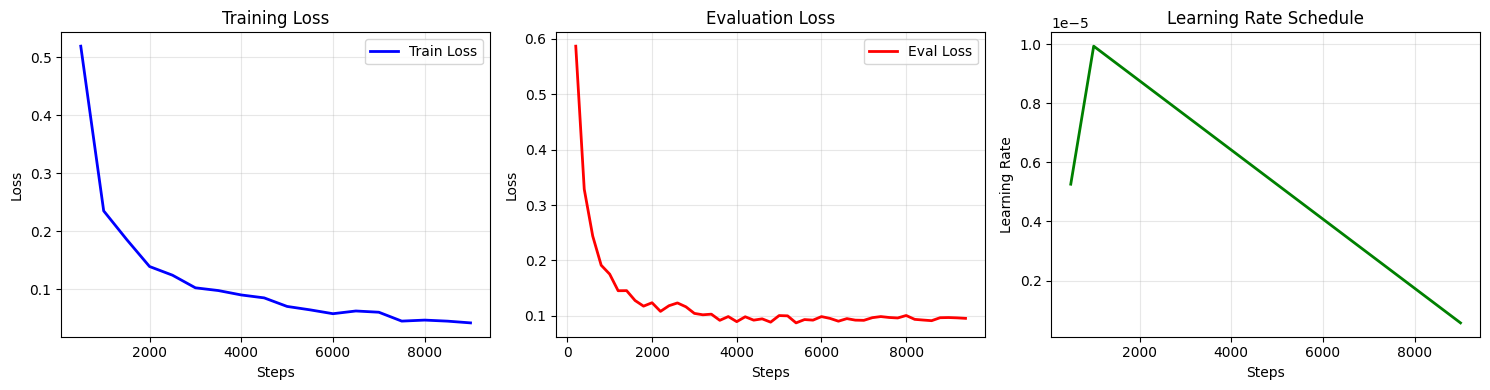

In [ ]:
plot_training_curves(full_denoise_trainer)

In [ ]:
evaluate_on_test_set(
    trainer=full_denoise_trainer,
    tokenizer=tokenizer,
    test_samples=test
)

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 N N N 0 0 0 0
N N N 0 0 0 0 0
6/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 0 0
N N 0 0 0 0
4/6
привет как дела что делаешь переведи пять тысяч на вклад
0 N N N N 0 0 0 0 0
N N N N N 0 0 0 0 0
9/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 0 N 0 N N N N 0 0 0
N N N N N N N N 0 0 0
8/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 0 N N N N
N N N 0 0 0 0
0/7
переведи деньги срочно сделай тише я сказал
0 0 0 0 0 N N
0 0 0 N N N N
5/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N N N
N N N N N N N 0 0 0
0/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    63.01%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 63.46%
  Recall:    80.49%
  F1:        70.97%

КЛАСС N (ШУМ):
  Precision: 61.90%
  Recall:    40.62%
  F1:        49

In [ ]:
model_save_path = "full_denoise_model"
full_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### bctw_labels

In [ ]:
train_bctw_noise_dataset, test_bctw_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_bctw.json', tokenizer, test_size=0.2, seed=42, verbose=True)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['сколько', 'я', 'должен', 'заплатить', 'ась', 'где', 'в', 'та', 'надоели', 'этом', 'месяце'], 'denoise_labels': ['0', '0', '0', '0', 'N', 'N', '0', 'N', 'N', '0', '0'], 'classification_labels': 'bill_balance'}

Пример из train (после токенизации):
{'input_ids': [0, 47381, 784, 15856, 94446, 1117, 6, 43460, 4851, 49, 489, 11064, 22940, 3920, 45666, 103, 2], 'mask': [False, True, True, True, False, True, False, True, True, True, True, False, True, True, False, True, False], 'labels': array([-100,    0,    0,    0, -100,    0, -100,    1,    1,    0,    1,
       -100,    1,    0, -100,    0, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

bctw_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=2)
optimizer = AdamW(bctw_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
bctw_denoise_trainer = Trainer(
    model=bctw_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_bctw_noise_dataset,
    eval_dataset=test_bctw_noise_dataset,
    compute_metrics=compute_metrics)
bctw_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Precision 0,Recall 0,F1 0,Precision N,Recall N,F1 N,Macro Precision,Macro Recall,Macro F1
200,No log,0.294414,87.944712,91.298263,85.032970,88.054309,84.765473,91.131062,87.833084,88.031868,88.082016,87.943697
400,No log,0.154246,93.950321,93.484163,95.046772,94.258992,94.478632,92.750461,93.606571,93.981398,93.898617,93.932781
600,0.366332,0.131543,95.288462,94.703134,96.373256,95.530896,95.953114,94.101359,95.018216,95.328124,95.237307,95.274556
800,0.366332,0.101116,96.410256,96.450971,96.687625,96.569153,96.365472,96.106729,96.235927,96.408222,96.397177,96.402540
1000,0.127217,0.110046,96.458333,95.651847,97.661402,96.646180,97.380625,95.141802,96.248196,96.516236,96.401602,96.447188
1200,0.127217,0.103822,96.810897,96.428571,97.508051,96.965307,97.239212,96.047995,96.639932,96.833892,96.778023,96.802620
1400,0.127217,0.093380,96.891026,96.057375,98.075449,97.055922,97.844383,95.594898,96.706561,96.950879,96.835174,96.881242
1600,0.088255,0.080060,97.263622,97.758714,96.986658,97.371156,96.730721,97.566706,97.146915,97.244718,97.276682,97.259035
1800,0.088255,0.093758,97.299679,96.756389,98.121454,97.434140,97.912050,96.400403,97.150347,97.334220,97.260928,97.292244
2000,0.067974,0.101517,97.339744,97.388974,97.523386,97.456134,97.285714,97.138782,97.212192,97.337344,97.331084,97.334163


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3300, training_loss=0.11758510589599609, metrics={'train_runtime': 1993.3143, 'train_samples_per_second': 13.244, 'train_steps_per_second': 1.656, 'total_flos': 575150906432352.0, 'train_loss': 0.11758510589599609, 'epoch': 4.0})

In [ ]:
final_report(bctw_denoise_trainer, test_bctw_noise_dataset)

              precision    recall  f1-score   support

Целевая речь       0.97      0.98      0.98     13042
         Шум       0.98      0.97      0.97     11918

    accuracy                           0.98     24960
   macro avg       0.98      0.97      0.98     24960
weighted avg       0.98      0.98      0.98     24960



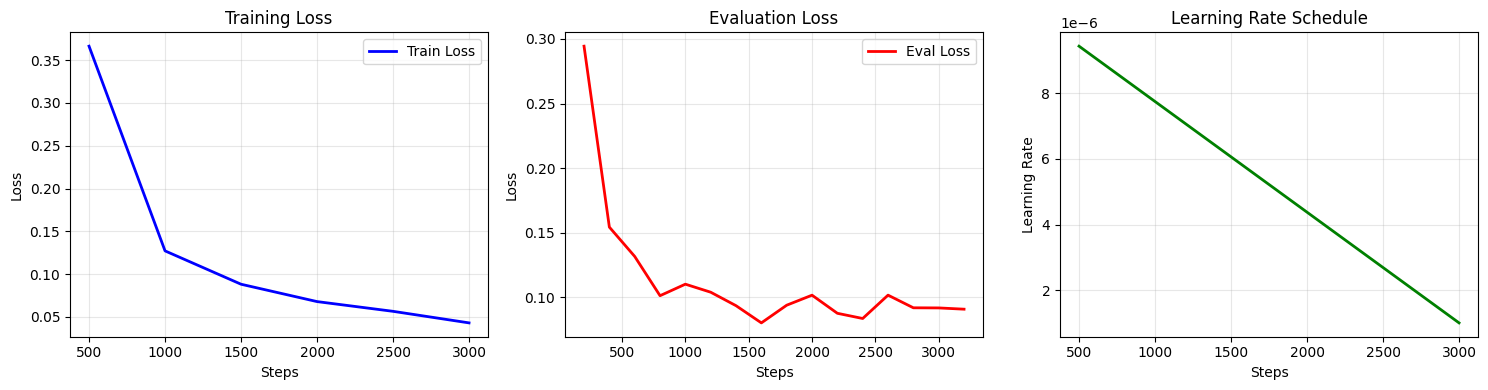

In [ ]:
plot_training_curves(bctw_denoise_trainer)

In [ ]:
evaluate_on_test_set(
    trainer=bctw_denoise_trainer,
    tokenizer=tokenizer,
    test_samples=test
)

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 0 0 0 0 0 0 0
N N N 0 0 0 0 0
5/8
выключи телевизор заблокируй карту срочно пожалуйста
N N 0 0 0 0
N N 0 0 0 0
6/6
привет как дела что делаешь переведи пять тысяч на вклад
N N N N N 0 0 0 0 0
N N N N N 0 0 0 0 0
10/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
N N N N N N N N 0 0 0
N N N N N N N N 0 0 0
11/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N 0 0 0 0
N N N 0 0 0 0
5/7
переведи деньги срочно сделай тише я сказал
0 0 0 N N 0 0
0 0 0 N N N N
5/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N N 0
N N N N N N N 0 0 0
1/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    78.08%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 73.58%
  Recall:    95.12%
  F1:        82.98%

КЛАСС N (ШУМ):
  Precision: 90.00%
  Recall:    56.25%
  F1:        

In [ ]:
model_save_path = "bctw_denoise_model"
bctw_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### travel+work (train) + banking+credit (test)

In [ ]:
train_banking_credit_noise_dataset, test_banking_credit_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_banking_credit.json', tokenizer, test_size=0.2, seed=42, verbose=True)

train_travel_work_noise_dataset, test_travel_work_noise_dataset = prepare_denoise_dataset_from_json('/content/denoiseML/data/noise_data_travel_work.json', tokenizer, test_size=0.2, seed=42, verbose=True)

Пример из train (исходные данные):
{'text': ['на', 'что', 'татумастер', 'годятся', 'мя', 'мои', 'несчаст', 'шедевры', 'понятно'], 'denoise_labels': ['0', '0', 'N', '0', 'N', '0', 'N', '0', 'N'], 'classification_labels': 'redeem_rewards'}

Пример из train (после токенизации):
{'input_ids': [0, 29, 414, 145075, 723, 12544, 5532, 32369, 36110, 64816, 19671, 28312, 65110, 1125, 12957, 227, 93870, 2], 'mask': [False, True, True, False, False, True, False, True, True, True, False, True, False, False, False, True, True, False], 'labels': array([-100,    0,    0, -100, -100,    1, -100,    0,    1,    0, -100,
          1, -100, -100, -100,    0,    1, -100])}



Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['на', 'что', 'татумастер', 'годятся', 'мя', 'мои', 'несчаст', 'шедевры', 'понятно'], 'denoise_labels': ['0', '0', 'N', '0', 'N', '0', 'N', '0', 'N'], 'classification_labels': 'redeem_rewards'}

Пример из train (после токенизации):
{'input_ids': [0, 29, 414, 145075, 723, 12544, 5532, 32369, 36110, 64816, 19671, 28312, 65110, 1125, 12957, 227, 93870, 2], 'mask': [False, True, True, False, False, True, False, True, True, True, False, True, False, False, False, True, True, False], 'labels': array([-100,    0,    0, -100, -100,    1, -100,    0,    1,    0, -100,
          1, -100, -100, -100,    0,    1, -100])}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam
import numpy as np

tw_bc_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=2)
optimizer = AdamW(tw_bc_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
tw_bc_denoise_trainer = Trainer(
    model=tw_bc_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_travel_work_noise_dataset,
    eval_dataset=test_banking_credit_noise_dataset,
    compute_metrics=compute_metrics)
tw_bc_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Precision 0,Recall 0,F1 0,Precision N,Recall N,F1 N,Macro Precision,Macro Recall,Macro F1
200,No log,0.191009,92.415010,92.891278,92.974589,92.932915,91.862881,91.767554,91.815193,92.377080,92.371072,92.374054
400,No log,0.124187,95.509942,96.090226,95.515695,95.802099,94.847132,95.503286,95.174078,95.468679,95.509491,95.488088
600,0.296803,0.115968,96.103271,96.829710,95.874439,96.349707,95.280438,96.368039,95.821152,96.055074,96.121239,96.085430
800,0.296803,0.099070,96.664529,97.747336,95.994021,96.862745,95.459166,97.440332,96.439575,96.603251,96.717176,96.651160
1000,0.091037,0.104963,96.776780,96.481372,97.548580,97.012041,97.126840,95.883777,96.501305,96.804106,96.716179,96.756673
1200,0.091037,0.090791,97.033355,97.150104,97.324365,97.237157,96.897747,96.696645,96.797091,97.023926,97.010505,97.017124
1400,0.091037,0.090163,97.201732,97.243332,97.548580,97.395717,97.153272,96.800415,96.976523,97.198302,97.174498,97.186120
1600,0.058188,0.090783,97.185696,97.355446,97.399103,97.377270,96.989098,96.938776,96.963930,97.172272,97.168939,97.170600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1680, training_loss=0.1380168188185919, metrics={'train_runtime': 609.4546, 'train_samples_per_second': 22.053, 'train_steps_per_second': 2.757, 'total_flos': 295330659300864.0, 'train_loss': 0.1380168188185919, 'epoch': 4.0})

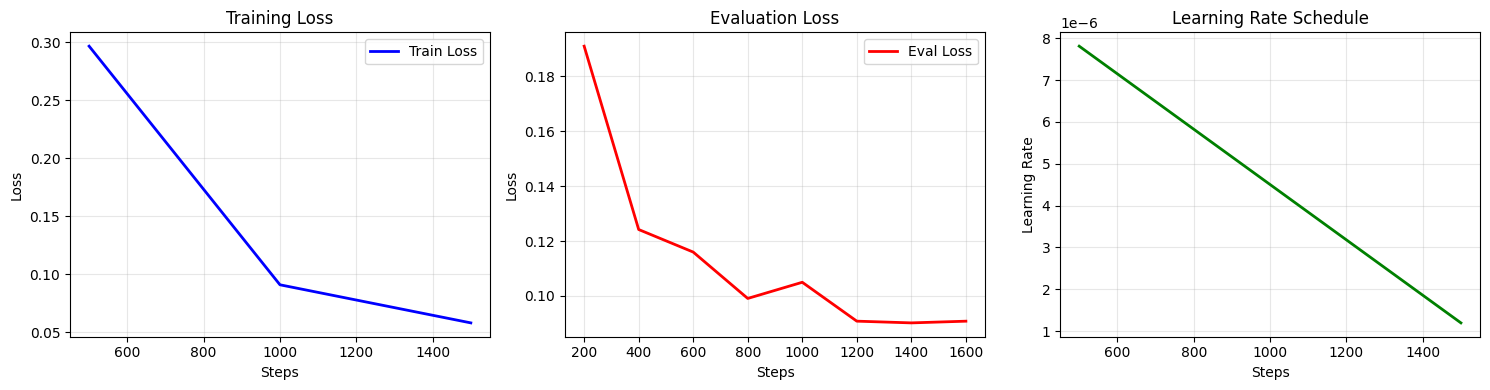

In [ ]:
plot_training_curves(tw_bc_denoise_trainer)

In [ ]:
final_report(tw_bc_denoise_trainer, test_banking_credit_noise_dataset)

              precision    recall  f1-score   support

Целевая речь       0.97      0.97      0.97      6690
         Шум       0.97      0.97      0.97      5782

    accuracy                           0.97     12472
   macro avg       0.97      0.97      0.97     12472
weighted avg       0.97      0.97      0.97     12472



In [ ]:
evaluate_on_test_set(
    trainer=tw_bc_denoise_trainer,
    tokenizer=tokenizer,
    test_samples=test,
)

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 N 0 0 0 0 0 0
N N N 0 0 0 0 0
6/8
выключи телевизор заблокируй карту срочно пожалуйста
N N 0 0 0 0
N N 0 0 0 0
6/6
привет как дела что делаешь переведи пять тысяч на вклад
N N N N N 0 0 0 0 0
N N N N N 0 0 0 0 0
10/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
N N N N N N N N 0 0 0
N N N N N N N N 0 0 0
11/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 0 0 0 0 0
N N N 0 0 0 0
4/7
переведи деньги срочно сделай тише я сказал
0 0 0 N N N N
0 0 0 N N N N
7/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N N 0
N N N N N N N 0 0 0
1/10

ОСНОВНЫЕ МЕТРИКИ
Token Accuracy:    80.82%

КЛАСС 0 (ЦЕЛЕВАЯ РЕЧЬ):
  Precision: 76.47%
  Recall:    95.12%
  F1:        84.78%

КЛАСС N (ШУМ):
  Precision: 90.91%
  Recall:    62.50%
  F1:        

In [ ]:
model_save_path = "tw_bc_denoise_model"
tw_bc_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]